In [ ]:
"""
Author    : Mohammad Norizadeh Cherloo
Project   : MNIST Digit Classification
Algorithm : GoogleNet modern version (2014) – PyTorch
"""

import torch
from sklearn import  metrics
from matplotlib import pyplot as plt
from sklearn import preprocessing as prep
from torch.utils.data import TensorDataset,DataLoader,Dataset
import pandas as pd
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.datasets import load_digits
from torch.nn import functional as F
import torchvision
from torchvision.transforms import ToTensor, Lambda
from torch import nn, optim

c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\pandas\core\arrays\masked.py:60: UserWarning: Pandas requires version '1.3.6' or newer of 'bottleneck' (version '1.3.5' currently installed).
  from pandas.core import (
c:\onlinebme\course-online\Pytorch\PyTorch\.conda\lib\site-packages\torchvision\io\image.py:13: UserWarning: Failed to load image Python extension: '[WinError 127] The specified procedure could not be found'If you don't plan on using image functionality from `torchvision.io`, you can ignore this warning. Otherwise, there might be something wrong with your environment. Did you have `libjpeg` or `libpng` installed before building `torchvision` from source?
  warn(


In [2]:
from torch.utils.data import DataLoader, random_split

# %% MNIST dataset
num_classes = 10
batch_size = 32

# target_transform = Lambda(
#     lambda y: torch.zeros(num_classes).scatter_(0, torch.tensor(y), 1)
# )

full_train_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=True,
    transform=ToTensor(),
    download=True
)

test_dataset = torchvision.datasets.MNIST(
    root='./data',
    train=False,
    transform=ToTensor(),
)


In [3]:
train_size = 50000
val_size   = 10000

train_dataset, val_dataset = random_split(
    full_train_dataset,
    [train_size, val_size]
)


In [4]:
train_loader = DataLoader(
    train_dataset,
    batch_size=batch_size,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=batch_size,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=batch_size,
    shuffle=False
)


In [5]:
class LightGoogleNet(nn.Module):
    def __init__(self,num_classes= 10):
        super(LightGoogleNet, self).__init__()
        # ******************* stem ********************#
        self.stem= nn.Sequential(nn.LazyConv2d(out_channels=16,kernel_size=5,padding=2),
                                 nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU(),
                                 nn.MaxPool2d(kernel_size=3,stride=2), 
                                 nn.LazyConv2d(out_channels=16,kernel_size=1),
                                 nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU()
                                 )
        # ******************* block1 ********************#
        self.block1= nn.Sequential(Inception(c1=8,c2=(8,16),c3=(4,8),c4=8),
                                  Inception(c1=16,c2=(16,24),c3=(8,16),c4=8),
                                  nn.MaxPool2d(kernel_size=3,stride=2))                
        
        # ******************* block2 ********************#                          
        self.block2_1= Inception(c1=16,c2=(16,32),c3=(8,16),c4=16)
        self.block2_2= Inception(c1=24,c2=(24,32),c3=(8,16),c4=16)
        # ******************* block3 ********************#
        self.block3= Inception(c1=32,c2=(32,48),c3=(8,16),c4=16)
        # ******************* block1 ********************#
        # ******************* head ********************#
        self.head= nn.Sequential(nn.AdaptiveAvgPool2d((3,3)),
                                 nn.Flatten(),
                                 nn.Dropout(0.4),
                                 nn.LazyLinear(num_classes))
        
    def forward(self,x):
       # X: bs x 1 x H x W
       out= self.stem(x)
       out= self.block1(out)
       out= self.block2_1(out)
       out= self.block2_2(out)
       out= self.block3(out)
       out= self.head(out)
       return out

class Inception(nn.Module):
    def __init__(self, c1=8, c2=(8,16),c3=(8,16),c4=16 ):
        super(Inception, self).__init__()
        self.b1= nn.Sequential(nn.LazyConv2d(out_channels=c1,kernel_size=1),
                                 nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU())
        self.b2= nn.Sequential(nn.LazyConv2d(out_channels=c2[0],kernel_size=1),
                               nn.LazyBatchNorm2d(momentum=0.1),
                               nn.ReLU(),
                                 
                                nn.LazyConv2d(out_channels=c2[1],kernel_size=3,padding=1),
                                nn.LazyBatchNorm2d(momentum=0.1),
                                nn.ReLU()) 
        
        self.b3= nn.Sequential(nn.LazyConv2d(out_channels=c3[0],kernel_size=1),
                                 nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU(),
                                 
                                 nn.LazyConv2d(out_channels=c3[1],kernel_size=5,padding=2),
                                 nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU()) 
        
        self.b4= nn.Sequential(nn.MaxPool2d(kernel_size=3,stride=1,padding=1),
                                 nn.LazyConv2d(out_channels=c4,kernel_size=1),
                                 nn.LazyBatchNorm2d(momentum=0.1),
                                 nn.ReLU()) 
    def forward(self,x):
        b1= self.b1(x)
        b2= self.b2(x)
        b3= self.b3(x)
        b4= self.b4(x)
        out= torch.cat((b1,b2,b3,b4),dim=1)
        return out 


In [6]:
model= LightGoogleNet(num_classes= 10)
n_out=10

criterion= nn.CrossEntropyLoss()
optimizer= optim.Adam(params=model.parameters(),
                      lr=0.001)

# optimizer= optim.SGD(params=model.parameters(),
#                       lr=0.01,momentum=0.9)

Loss(0:0): 2.414686 **** Valid Acc:10.360%
Loss(0:500): 0.240283 **** Valid Acc:96.590%
Loss(0:1000): 0.162628 **** Valid Acc:97.660%
Loss(0:1500): 0.130739 **** Valid Acc:97.830%
Loss(1:0): 0.099975 **** Valid Acc:98.140%
Loss(1:500): 0.052341 **** Valid Acc:97.900%
Loss(1:1000): 0.049813 **** Valid Acc:98.430%


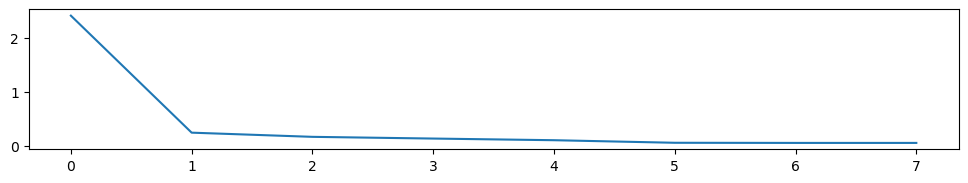

In [7]:
cost=[]
epoch=2
for iter in range(epoch):
     er=[]
     for i,(xbatch,ybatch) in enumerate(train_loader):
          model.train()
          # farward pass
          ypred= model(xbatch)
          optimizer.zero_grad()
          loss= criterion(ypred,ybatch.long())
          loss.backward()
          optimizer.step()

          er.append(loss.detach()) 
          if i%500==0:
               model.eval()
               loss= torch.mean(torch.tensor(er))
               cost.append(loss)
               # validation
               with torch.no_grad():
                    y_pred=[]
                    y_true=[]
                    for j,(xbatch,ybatch) in enumerate(val_loader):
                         # farward pass
                         ypred= model(xbatch)
                         ypred= torch.argmax(ypred,dim=1)
                         y_pred.extend(ypred.numpy())
                         y_true.extend(ybatch.numpy())
                         
                    y_pred= np.array(y_pred)
                    y_true= np.array(y_true)
                    accuracy= np.sum(y_true==y_pred)/y_pred.shape[0]*100
                    print(f'Loss({iter}:{i}): {loss:.6f} **** Valid Acc:{accuracy:.3f}%')
               model.train()
cost=torch.tensor(cost)
plt.figure(figsize=(12,4))
plt.subplot(2,1,1)
plt.plot(cost)
plt.show()

Total accuracy:98.600%
accuracy0:99.694%
accuracy1:98.943%
accuracy2:99.612%
accuracy3:99.010%
accuracy4:97.760%
accuracy5:98.094%
accuracy6:98.434%
accuracy7:98.054%
accuracy8:98.563%
accuracy9:97.721%


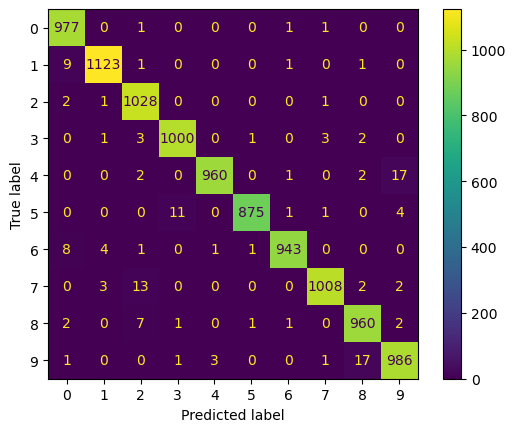

In [8]:
# validation
y_pred=[]
y_true=[]
model.eval()
with torch.no_grad():
    for i,(xbatch,ybatch) in enumerate(test_loader):
        # farward pass
        ypred= model(xbatch)
        ypred= torch.argmax(ypred,dim=1)
        y_pred.extend(ypred.numpy())
        y_true.extend(ybatch.numpy())
        
    y_pred= np.array(y_pred)
    y_true= np.array(y_true)

    from sklearn.metrics import confusion_matrix,ConfusionMatrixDisplay
    #%% test trained Neural Network
    C= confusion_matrix(y_true,y_pred)
    # print(C)
    accuracy= np.sum(np.diag(C))/ np.sum(C) *100
    print(f'Total accuracy:{accuracy:.3f}%')

for i in range(n_out):
    accuracyi= C[i,i]/ np.sum(C[i,:]) *100
    print(f'accuracy{i}:{accuracyi:.3f}%')
# plt.figure()
disp= ConfusionMatrixDisplay(C)
disp.plot()
plt.show()